First: lets see what our current un-tidy data looks like:

In [229]:
#import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
sns.set_theme(style='ticks')

#Load the dataset and take a look at the first five rows
df = pd.read_csv("fed_rd_year&gdp.csv")
df.head()

,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0,1980_gdp2797000000000.0,1981_gdp3138000000000.0,1982_gdp3314000000000.0,1983_gdp3541000000000.0,1984_gdp3953000000000.0,...,2008_gdp14752000000000.0,2009_gdp14415000000000.0,2010_gdp14799000000000.0,2011_gdp15379000000000.0,2012_gdp16027000000000.0,2013_gdp16516000000000.0,2014_gdp17244000000000.0,2015_gdp17983000000000.0,2016_gdp18470000000000.0,2017_gdp19177000000000.0
0,DHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1155000000,1258000000,1009000000,848000000,527000000,737000000,1092000000,960000000,602000000,735000000
1,DOC,8.190000e+08,8.370000e+08,8.710000e+08,9.520000e+08,9.450000e+08,8.290000e+08,6.930000e+08,7.000000e+08,7.550000e+08,...,1379000000,1594000000,1521000000,1357000000,1373000000,1397000000,1641000000,1596000000,1730000000,1824000000
2,DOD,3.569600e+10,3.796700e+10,3.702200e+10,3.717400e+10,3.700500e+10,4.173700e+10,4.689300e+10,5.100800e+10,5.813900e+10,...,94247000000,93527000000,94325000000,88220000000,81543000000,70583000000,70341000000,69522000000,75213000000,51862000000
3,DOE,1.088200e+10,1.374100e+10,1.566300e+10,1.561200e+10,1.522600e+10,1.479800e+10,1.216000e+10,1.112900e+10,1.173100e+10,...,11343000000,11823000000,12329000000,11902000000,11839000000,11528000000,12686000000,15033000000,15504000000,15032000000
4,DOT,1.142000e+09,1.095000e+09,1.156000e+09,1.004000e+09,1.048000e+09,9.780000e+08,7.020000e+08,8.000000e+08,1.018000e+09,...,1016000000,1062000000,1221000000,1064000000,1007000000,881000000,843000000,926000000,910000000,936000000


In [207]:
#check for missing values
df_null_counts = df.isnull().sum()
print(df_null_counts)

department                  0
1976_gdp1790000000000.0     1
1977_gdp2028000000000.0     1
1978_gdp2278000000000.0     1
1979_gdp2570000000000.0     1
1980_gdp2797000000000.0     1
1981_gdp3138000000000.0     1
1982_gdp3314000000000.0     1
1983_gdp3541000000000.0     1
1984_gdp3953000000000.0     1
1985_gdp4270000000000.0     1
1986_gdp4536000000000.0     1
1987_gdp4782000000000.0     1
1988_gdp5155000000000.0     1
1989_gdp5570000000000.0     1
1990_gdp5915000000000.0     1
1991_gdp6110000000000.0     1
1992_gdp6435000000000.0     1
1993_gdp6795000000000.0     1
1994_gdp7198000000000.0     1
1995_gdp7583000000000.0     1
1996_gdp7978000000000.0     1
1997_gdp8483000000000.0     1
1998_gdp8955000000000.0     1
1999_gdp9511000000000.0     1
2000_gdp10148000000000.0    1
2001_gdp10565000000000.0    1
2002_gdp10877000000000.0    0
2003_gdp11332000000000.0    0
2004_gdp12089000000000.0    0
2005_gdp12889000000000.0    0
2006_gdp13685000000000.0    0
2007_gdp14323000000000.0    0
2008_gdp14

At this point we can make two observations: 

1. This data frame is messy according to Wickham because the column headers are values and not variable names (which should instead be years). We also have multiple variables stored in one column (year number and a gdp figure), which violates tidy data. 
2. There are missing values in the data frame from years 1976 to year 2001 in the DHS department. After further research, I uncovered that the department of homeland security was created in 2002, as a response for the 2001 9/11 terrorist attack. This means the data is missing not at random and should be kept as missing.


Now we will tidy the data to ensure: 
1. Each variable forms a column.
2. Each observation forms a row.
3. Each type of observational unit forms a table.

In [208]:
# create a new tidy data frame with the year, gdp, department, and rd_budget columns by using method chaining
df_tidy = (
    df
    # appease tidy data critera 1 & 2 by melting the wide year_gdp columns into a single column and 
    # then spliting that column into two separate columns (year and gdp)
    .melt(id_vars=['department'], var_name='year_gdp', value_name='rd_budget')
    .assign(
       # Extract the year from the string by splitting on '_gdp' and taking the left side
       year=lambda x: x['year_gdp'].str.split('_gdp').str[0],
       # Extract the gdp figure from the string by splitting on '_gdp' and taking the right side
       gdp=lambda x: x['year_gdp'].str.split('_gdp').str[1].str.replace('.0','', regex=False)
    )
    # make sure each observational unit is not a string and is instead a numeric value
    .astype({'year': int, 'gdp': float})
    # drop the redundant year_gdp column that we no longer need
    .drop(columns=['year_gdp'])

    .assign(
    # convert the rd_budget and gdp columns from dollars to billions of dollars for easier interpretation
        rd_budget=lambda x: x['rd_budget'] / 1e9,
        gdp=lambda x: x['gdp'] / 1e9)
    # rename the columns 
    [['year', 'gdp', 'department', 'rd_budget']]
)
print(df_tidy)

dept_rd = df_tidy[['year', 'department', 'rd_budget']]
gdp_by_year = df_tidy[['year', 'gdp']].drop_duplicates()

print("Data frame containging the R&D budget for each department by year:")
print(dept_rd)

print("\nData frame containing the GDP for each year:")
print(gdp_by_year)


     year      gdp department  rd_budget
0    1976   1790.0        DHS        NaN
1    1976   1790.0        DOC      0.819
2    1976   1790.0        DOD     35.696
3    1976   1790.0        DOE     10.882
4    1976   1790.0        DOT      1.142
..    ...      ...        ...        ...
583  2017  19177.0        NIH     33.052
584  2017  19177.0        NSF      6.040
585  2017  19177.0      Other      1.553
586  2017  19177.0       USDA      2.625
587  2017  19177.0         VA      1.367

[588 rows x 4 columns]
Data frame containging the R&D budget for each department by year:
     year department  rd_budget
0    1976        DHS        NaN
1    1976        DOC      0.819
2    1976        DOD     35.696
3    1976        DOE     10.882
4    1976        DOT      1.142
..    ...        ...        ...
583  2017        NIH     33.052
584  2017        NSF      6.040
585  2017      Other      1.553
586  2017       USDA      2.625
587  2017         VA      1.367

[588 rows x 3 columns]

Data fra

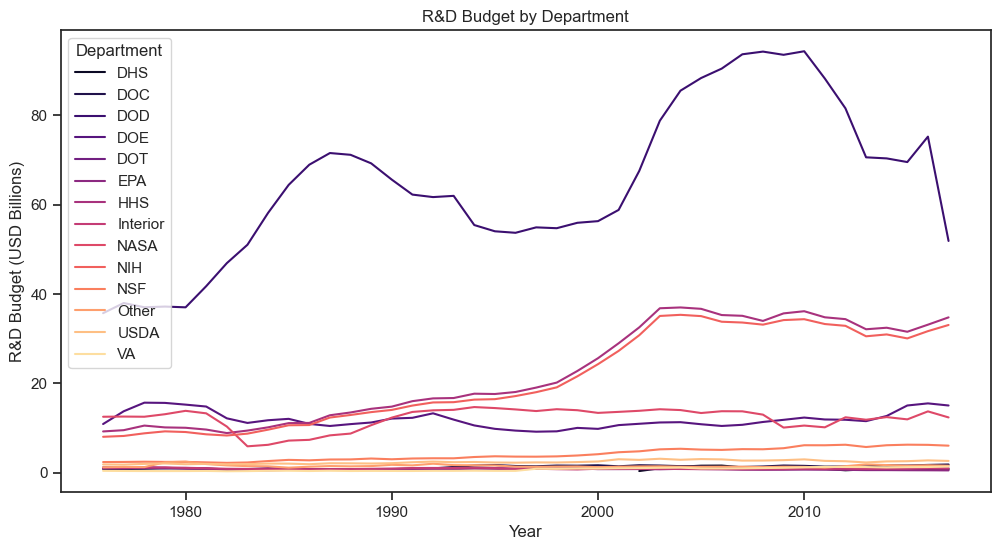

,year,department,rd_budget
0,1976,DHS,NaN
1,1976,DOC,0.819
2,1976,DOD,35.696
3,1976,DOE,10.882
4,1976,DOT,1.142


In [214]:
# Create a visualization of the R&D budget for each department over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=dept_rd, 
             x='year', 
             y='rd_budget', 
             hue='department',
             palette='magma')

plt.title('R&D Budget by Department')
plt.xlabel('Year')
plt.ylabel('R&D Budget (USD Billions)')
plt.legend(title='Department')
plt.show()
dept_rd.head()


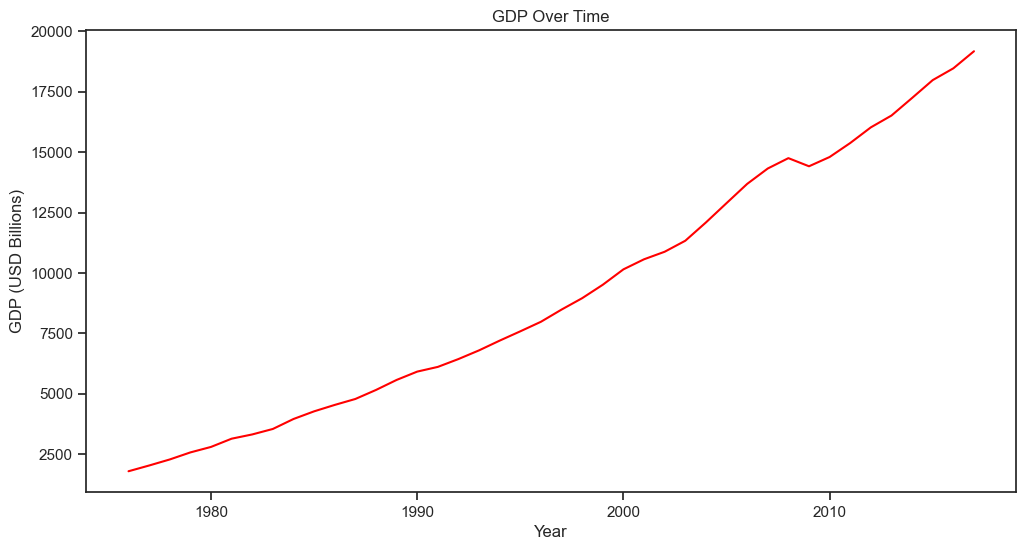

In [209]:
## Create a visualization of the GDP over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=gdp_by_year, x='year', y='gdp', color='red')
plt.title('GDP Over Time')
plt.xlabel('Year')
plt.ylabel('GDP (USD Billions)')
plt.show()  


In [221]:
## Visualization 2: Total R&D Spending as a Percentage of GDP Over Time

# Use a pivot table to sum the total R&D budget across all departments by year
total_rd = dept_rd.pivot_table(
    index='year',
    values='rd_budget',
    aggfunc='sum'
).reset_index()
print(total_rd)

# Use a pivot table to find the max R&D budget across all departments by year
max_rd = dept_rd.pivot_table(
    index='year',
    values='rd_budget',
    aggfunc='max'
).reset_index()
print(max_rd)

# find the pecentage of the total R&D budget compared to the GDP for each year
percentage_df = (
    total_rd
    #merge the total_rd and gdp_by_year data frames
    .merge(gdp_by_year, on='year')
    #divide total R&D budget by  the GDP for each year and assign that value to a new column called pct_of_gdp
    .assign(pct_of_gdp=lambda x: (x['rd_budget'] / x['gdp']) * 100)
)
print(percentage_df)


    year  rd_budget
0   1976     86.227
1   1977     91.807
2   1978     94.864
3   1979     96.601
4   1980     96.305
5   1981     98.304
6   1982     95.448
7   1983     95.010
8   1984    105.371
9   1985    114.818
10  1986    118.231
11  1987    125.314
12  1988    126.800
13  1989    128.912
14  1990    129.126
15  1991    130.008
16  1992    133.172
17  1993    132.080
18  1994    127.278
19  1995    124.883
20  1996    123.978
21  1997    127.018
22  1998    129.698
23  1999    136.867
24  2000    142.299
25  2001    153.197
26  2002    170.354
27  2003    192.010
28  2004    199.104
29  2005    200.099
30  2006    199.429
31  2007    201.827
32  2008    200.857
33  2009    201.275
34  2010    204.556
35  2011    194.256
36  2012    188.944
37  2013    172.121
38  2014    175.383
39  2015    174.608
40  2016    185.885
41  2017    163.606
    year  rd_budget
0   1976     35.696
1   1977     37.967
2   1978     37.022
3   1979     37.174
4   1980     37.005
5   1981     41.737


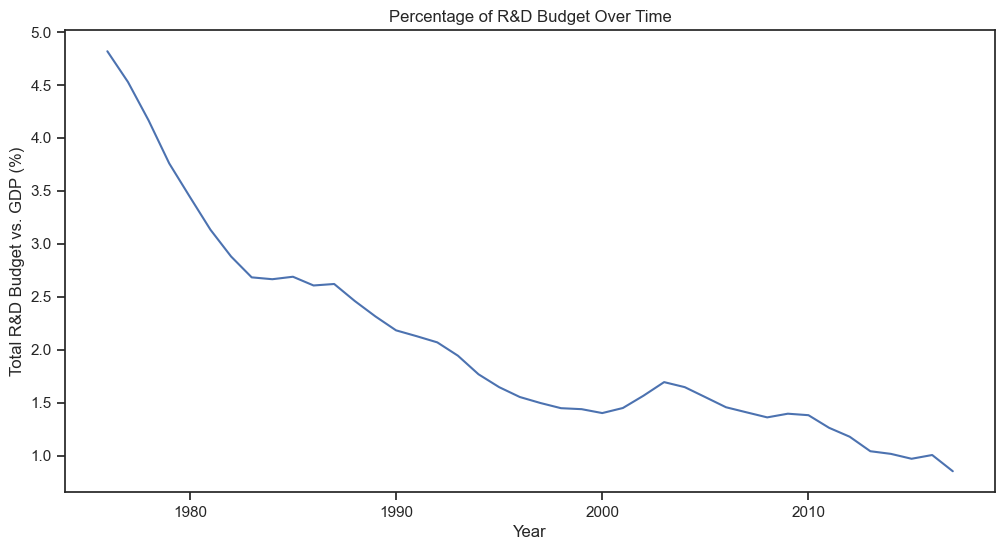

In [ ]:
#create a line plot to visualize the percentage of the total R&D budget compared to the GDP for each year
plt.figure(figsize=(12, 6))
sns.lineplot(data=percentage_df, x= 'year', y= 'pct_of_gdp')
plt.title('R&D Budget as a Percentage of GDP Over Time')
plt.xlabel('Year')
plt.ylabel('Total R&D Budget vs. GDP (%)')
plt.show()

     year department  rd_budget  rd_budget_total  pct_of_total
0    1976        DHS        NaN           86.227           NaN
1    1976        DOC      0.819           86.227      0.949819
2    1976        DOD     35.696           86.227     41.397706
3    1976        DOE     10.882           86.227     12.620177
4    1976        DOT      1.142           86.227      1.324411
..    ...        ...        ...              ...           ...
583  2017        NIH     33.052          163.606     20.202193
584  2017        NSF      6.040          163.606      3.691796
585  2017      Other      1.553          163.606      0.949232
586  2017       USDA      2.625          163.606      1.604464
587  2017         VA      1.367          163.606      0.835544

[588 rows x 5 columns]


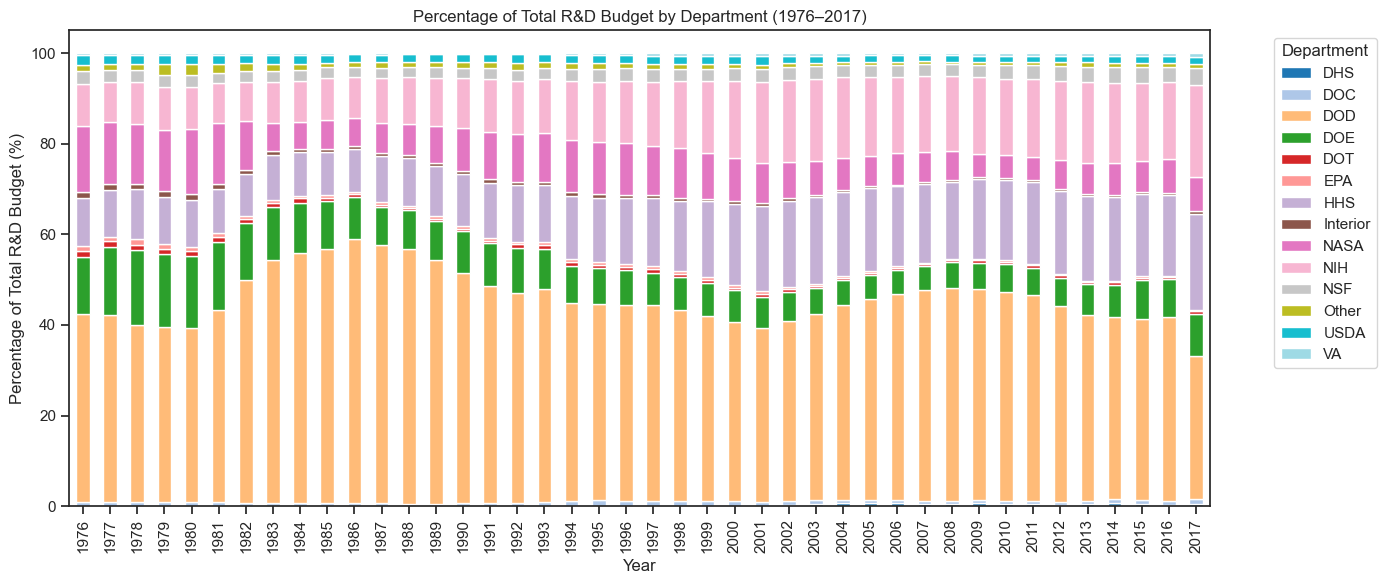

In [235]:
# Make a bar chart showing the percentage of each department of total R&D budget for each year
dept_percentage = (
    dept_rd
    # merge the dept_rd and total_rd data frames to get the total R&D budget for each year
    .merge(total_rd, on='year', suffixes=('', '_total'))
    # calculate the percentage of each department's R&D budget compared to the total R&D budget for each year and assign that value to a new column called pct_of_total
    .assign(pct_of_total=lambda x: (x['rd_budget'] / x['rd_budget_total']) * 100)
)
print(dept_percentage)

# create a bar chart showing the percentage of each department of total R&D budget for each year

# Pivot to wide format — each department becomes its own column
dept_pivot = dept_percentage.pivot(index='year', columns='department', values='pct_of_total')
dept_pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.title('Percentage of Total R&D Budget by Department (1976–2017)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total R&D Budget (%)')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
